In [1]:
import torch 
import torch.nn as nn
import numpy as np
import cv2
import matplotlib.pyplot as plt


In [3]:
print("torch version : {}".format(torch.__version__))

torch version : 2.10.0


In [6]:
digit_0_array_og = cv2.imread("data/mnist_0.jpg")
digit_1_array_og = cv2.imread("data/mnist_1.jpg")

In [7]:
digit_0_array_gray = cv2.imread("data/mnist_0.jpg", cv2.IMREAD_GRAYSCALE)
digit_1_array_gray = cv2.imread("data/mnist_1.jpg", cv2.IMREAD_GRAYSCALE)


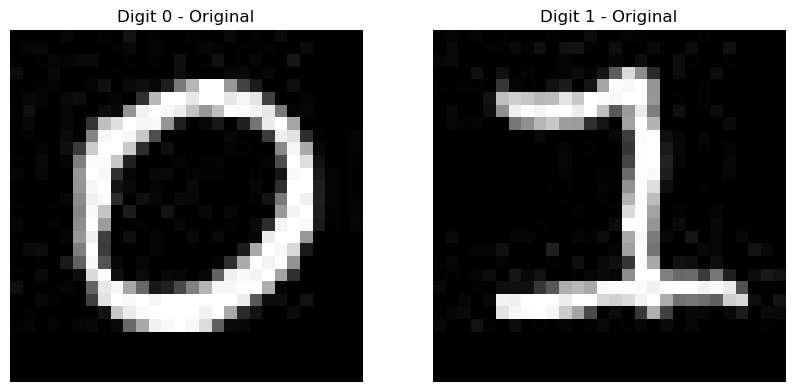

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(cv2.cvtColor(digit_0_array_og, cv2.COLOR_BGR2RGB))
axs[0].set_title("Digit 0 - Original")
axs[0].axis('off')
axs[1].imshow(cv2.cvtColor(digit_1_array_og, cv2.COLOR_BGR2RGB))
axs[1].set_title("Digit 1 - Original")
axs[1].axis('off')
plt.show()

In [11]:
digit_0_array_og

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [7, 7, 7],
        [7, 7, 7],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[1, 1, 1],
        [0, 0, 0],
        [2, 2, 2],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)

In [12]:
digit_0_array_gray

array([[  0,   0,   0,   0,   7,   1,   0,   3,   0,  18,   0,   3,   0,
          0,   3,   0,   0,   9,   0,   2,   0,  11,   0,   1,   0,   0,
          0,   0],
       [  0,   7,   7,   0,   0,   0,   0,   0,   2,   8,   0,   4,   0,
          0,   0,   6,   4,   0,   2,   3,   2,   0,   0,  11,   0,   0,
          0,   0],
       [  1,   0,   2,   6,   4,   9,   9,   0,   0,   2,   0,   3,   1,
         15,   0,   2,  16,   0,   2,   7,   0,   0,  22,   0,   0,   0,
          0,   0],
       [ 12,   0,   0,   8,   1,   0,   0,   0,   2,   0,   0,   0,   0,
         14,   0,   0,   0,   7,   9,   0,   7,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   3,   5,   0,   0,   4,  16,   0,  10,  14,   6,  29,
        122, 182, 255, 255, 152,  66,  26,   0,   0,  15,   0,   0,   0,
          0,   0],
       [  0,   7,   5,   0,   9,  12,   0,   0,   4,   0,  49, 184, 255,
        255, 232, 255, 255, 231, 246, 227,  64,   0,   0,   4,   0,   0,
          0,   0],
       [  

In [16]:
img_tensor_0 = torch.tensor(digit_0_array_og, dtype=torch.float32) / 255.0
img_tensor_1 = torch.tensor(digit_1_array_og, dtype=torch.float32) / 255.0


In [17]:
img_tensor_0

tensor([[[0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000],
         ...,
         [0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000]],

        [[0.0000, 0.0000, 0.0000],
         [0.0275, 0.0275, 0.0275],
         [0.0275, 0.0275, 0.0275],
         ...,
         [0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000]],

        [[0.0039, 0.0039, 0.0039],
         [0.0000, 0.0000, 0.0000],
         [0.0078, 0.0078, 0.0078],
         ...,
         [0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000]],

        ...,

        [[0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000],
         ...,
         [0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000]],

        [[0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000],
         [0.

In [18]:
img_tensor_1.shape

torch.Size([28, 28, 3])

In [20]:
img_tensor_0.shape


torch.Size([28, 28, 3])

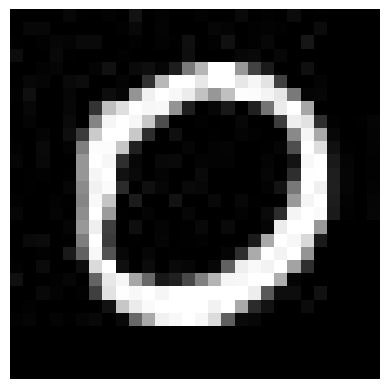

In [23]:
plt.imshow(img_tensor_0, cmap='gray')
plt.axis('off')
plt.show()

In [25]:
batch_tensor = torch.stack([img_tensor_0, img_tensor_1])
print("Batch tensor shape: {}".format(batch_tensor.shape))


Batch tensor shape: torch.Size([2, 28, 28, 3])


In [29]:
batch_input = batch_tensor.permute(0, 3, 1, 2)
print("Batch input shape (N, C, H, W): {}".format(batch_input.shape))


Batch input shape (N, C, H, W): torch.Size([2, 3, 28, 28])


In [34]:
# Create a tensor for CPU
# This will occupy CPU RAM
tensor_cpu = torch.tensor([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]], device='cpu')

# Create a tensor for GPU
# This will occupy GPU RAM
tensor_mps = torch.tensor([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]], device='mps')

In [36]:
# This uses CPU RAM
tensor_cpu = tensor_cpu * 5

# This uses MPS RAM
# Focus on MPS RAM Consumption
tensor_mps = tensor_mps * 5

In [37]:
print("Tensor on CPU: \n", tensor_cpu)
print("Tensor on MPS: \n", tensor_mps)

Tensor on CPU: 
 tensor([[ 25.,  50.],
        [ 75., 100.],
        [125., 150.]])
Tensor on MPS: 
 tensor([[ 25.,  50.],
        [ 75., 100.],
        [125., 150.]], device='mps:0')


In [39]:
# check Time
cpu_time = %timeit -o tensor_cpu * 5

1.26 μs ± 26 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [40]:
# check time
mps_time = %timeit -o tensor_mps * 5

1.43 μs ± 63.2 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [41]:
a = torch.tensor([[1, 2], [3, 4]])
b = torch.tensor([[5, 6], [7, 8]])
c = torch.tensor([[2], [2]])
d = a + b
e = d * c

In [42]:
d

tensor([[ 6,  8],
        [10, 12]])

In [43]:
e

tensor([[12, 16],
        [20, 24]])

In [44]:
e = d * c
e

tensor([[12, 16],
        [20, 24]])

In [46]:
# import torch
a = torch.tensor([[1, 2], [3, 4]])
b = torch.tensor([[5, 6], [7, 8]]) 
c = torch.tensor([[2, 2], [2, 2]])
d = a + b
e = d * c

In [ ]:
print(d)
print(e)

tensor([[ 6,  8],
        [10, 12]])
tensor([[12, 16],
        [20, 24]])
